# 02 — SGD: single-process vs Ray-parallel (local-SGD with averaging)

Answers: *"what if we parallelize SGD with Ray — is it actually faster?"*

For a model this small (50 features -> 51 numbers to communicate), naively parallelizing SGD by
synchronizing a gradient after every single mini-batch is usually **not** worth it — the Ray task
overhead (serialization, scheduling) per round dwarfs the few microseconds of actual compute per
mini-batch. Real distributed-SGD systems instead use **local SGD with periodic averaging**
(a.k.a. FedAvg-style training): shard the data across workers, let each worker run several local
epochs *without* communicating, then average the resulting weight vectors and (optionally)
broadcast the average back for another round. That's what this notebook implements and times
against a plain single-process `SGDClassifier` baseline.

Requires `ray` — install it first if it's not already in your environment:
`pip install ray` (run that in a terminal, or `!pip install ray` in a notebook cell, before
running the imports below).

Run `00_generate_synthetic_data.ipynb` first (with the same `N_ROWS`) so the cached arrays exist
under `data/`.

In [1]:
import gc
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

import ray

# ---------------------------------------------------------------------------
# CONFIG — every knob for this notebook lives here, each overridable from
# outside via env var so you don't have to hand-edit the notebook per run.
# ---------------------------------------------------------------------------
N_ROWS = int(os.environ.get("N_ROWS", 200_000))     # must match a size generated by 00_generate_synthetic_data.ipynb
N_FEATURES = int(os.environ.get("N_FEATURES", 50))
TEST_SIZE = float(os.environ.get("TEST_SIZE", 0.2))
RANDOM_STATE = int(os.environ.get("RANDOM_STATE", 42))
DATA_DIR = Path(os.environ.get("DATA_DIR", "data"))

LR_C = float(os.environ.get("LR_C", 1.0))                          # used to derive the matched alpha, see notebook 01
BASELINE_MAX_ITER = int(os.environ.get("BASELINE_MAX_ITER", 20))    # single-process SGDClassifier epochs
ROUNDS = int(os.environ.get("ROUNDS", 2))                           # Ray: communication (averaging) rounds
LOCAL_EPOCHS_TOTAL = int(os.environ.get("LOCAL_EPOCHS_TOTAL", 20))  # Ray: total local epochs across all rounds, per worker
WORKER_COUNTS = sorted(set(
    [int(x) for x in os.environ.get("WORKER_COUNTS", "1,2,4").split(",")] + [os.cpu_count()]
))

X_PATH = DATA_DIR / f"X_{N_ROWS}.npy"
Y_PATH = DATA_DIR / f"y_{N_ROWS}.npy"

if not (X_PATH.exists() and Y_PATH.exists()):
    raise FileNotFoundError(
        f"{X_PATH} / {Y_PATH} not found. Run 00_generate_synthetic_data.ipynb with "
        f"N_ROWS={N_ROWS} first."
    )

X = np.load(X_PATH)
y = np.load(Y_PATH)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
del X, y
gc.collect()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"CPU count available: {os.cpu_count()}")

Train: (160000, 50), Test: (40000, 50)
CPU count available: 8


## Baseline — single-process `SGDClassifier`

Uses a fixed epoch budget (`BASELINE_MAX_ITER`, default 20) rather than running to `tol`-based
convergence — see notebook 01's "capped SGD" discussion for why that's the realistic way to
budget SGD training time. It's normal for sklearn to print a `ConvergenceWarning` here: hitting
`max_iter` before its internal convergence check fires is the intended behavior, not a bug.

In [2]:
ALPHA = 1.0 / (LR_C * X_train.shape[0])  # matches LogisticRegression(C=LR_C), see notebook 01

t0 = time.perf_counter()
baseline_model = SGDClassifier(
    loss="log_loss", alpha=ALPHA, max_iter=BASELINE_MAX_ITER, tol=1e-3, random_state=RANDOM_STATE
)
baseline_model.fit(X_train, y_train)
baseline_time = time.perf_counter() - t0

baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_pred = baseline_model.predict(X_test)

print(f"single-process SGD fit time: {baseline_time:.2f}s ({baseline_model.n_iter_} epochs)")
print(f"accuracy={accuracy_score(y_test, baseline_pred):.4f} "
      f"auc={roc_auc_score(y_test, baseline_proba):.4f} "
      f"log_loss={log_loss(y_test, baseline_proba):.4f}")

single-process SGD fit time: 0.95s (20 epochs)
accuracy=0.7569 auc=0.8387 log_loss=0.5559


/Users/ankitwahane/.pyenv/versions/3.12.6/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## Ray-parallel local-SGD with periodic averaging

Each `LocalSGDWorker` actor owns one shard of the training data. `train_ray_sgd` runs several
*communication rounds*; within a round every worker independently runs `local_epochs` of
`partial_fit` on its own shard (no communication), then the driver averages every worker's
`(coef_, intercept_)` and broadcasts the average back out as the starting point for the next
round. With `rounds=1` this degenerates to plain one-shot parameter averaging (fastest, least
communication); more rounds trade extra communication for a solution closer to what training on
the full, unsharded data would give.

In [3]:
@ray.remote
class LocalSGDWorker:
    def __init__(self, X_shard, y_shard, alpha, random_state):
        self.X = X_shard
        self.y = y_shard
        self.classes = np.array([0.0, 1.0])
        self.model = SGDClassifier(
            loss="log_loss", alpha=alpha, max_iter=1, tol=None,
            warm_start=True, random_state=random_state, learning_rate="optimal",
        )
        self._initialized = False

    def set_weights(self, coef, intercept):
        self.model.coef_ = coef.copy()
        self.model.intercept_ = intercept.copy()
        self.model.classes_ = self.classes
        self._initialized = True

    def local_train(self, local_epochs):
        for _ in range(local_epochs):
            if not self._initialized:
                self.model.partial_fit(self.X, self.y, classes=self.classes)
                self._initialized = True
            else:
                self.model.partial_fit(self.X, self.y)
        return self.model.coef_, self.model.intercept_


def train_ray_sgd(X_train, y_train, n_workers, alpha, local_epochs, rounds, random_state=0):
    shard_bounds = np.linspace(0, len(X_train), n_workers + 1, dtype=int)
    workers = [
        LocalSGDWorker.remote(
            X_train[shard_bounds[i]:shard_bounds[i + 1]],
            y_train[shard_bounds[i]:shard_bounds[i + 1]],
            alpha,
            random_state + i,
        )
        for i in range(n_workers)
    ]

    coef = intercept = None
    for round_idx in range(rounds):
        pairs = ray.get([w.local_train.remote(local_epochs) for w in workers])
        coef = np.mean([p[0] for p in pairs], axis=0)
        intercept = np.mean([p[1] for p in pairs], axis=0)
        if round_idx < rounds - 1:
            ray.get([w.set_weights.remote(coef, intercept) for w in workers])

    for w in workers:
        ray.kill(w)

    final_model = SGDClassifier(loss="log_loss", alpha=alpha)
    final_model.coef_ = coef
    final_model.intercept_ = intercept
    final_model.classes_ = np.array([0.0, 1.0])
    return final_model

In [4]:
ray.init(ignore_reinit_error=True, log_to_driver=False)

LOCAL_EPOCHS_PER_ROUND = max(1, LOCAL_EPOCHS_TOTAL // ROUNDS)

ray_results = []
for n_workers in WORKER_COUNTS:
    t0 = time.perf_counter()
    ray_model = train_ray_sgd(
        X_train, y_train,
        n_workers=n_workers,
        alpha=ALPHA,
        local_epochs=LOCAL_EPOCHS_PER_ROUND,
        rounds=ROUNDS,
        random_state=RANDOM_STATE,
    )
    ray_time = time.perf_counter() - t0

    ray_proba = ray_model.predict_proba(X_test)[:, 1]
    ray_pred = ray_model.predict(X_test)

    ray_results.append({
        "n_workers": n_workers,
        "fit_time_s": ray_time,
        "speedup_vs_baseline": baseline_time / ray_time,
        "accuracy": accuracy_score(y_test, ray_pred),
        "auc": roc_auc_score(y_test, ray_proba),
        "log_loss": log_loss(y_test, ray_proba),
    })
    print(f"n_workers={n_workers}: {ray_time:.2f}s "
          f"({baseline_time / ray_time:.2f}x vs single-process baseline)")

ray_results_df = pd.DataFrame(ray_results).set_index("n_workers")
ray_results_df

2026-09-18 17:38:44,197	INFO worker.py:2024 -- Started a local Ray instance.


n_workers=1: 3.00s (0.32x vs single-process baseline)


n_workers=2: 2.13s (0.44x vs single-process baseline)


n_workers=4: 1.89s (0.50x vs single-process baseline)


n_workers=8: 4.38s (0.22x vs single-process baseline)


,fit_time_s,speedup_vs_baseline,accuracy,auc,log_loss
n_workers,,,,,
1,2.996201,0.315414,0.774850,0.859427,0.494936
2,2.125391,0.444645,0.770725,0.854522,0.611049
4,1.890349,0.499932,0.783275,0.868058,0.786056
8,4.380079,0.215760,0.789750,0.874800,1.307275


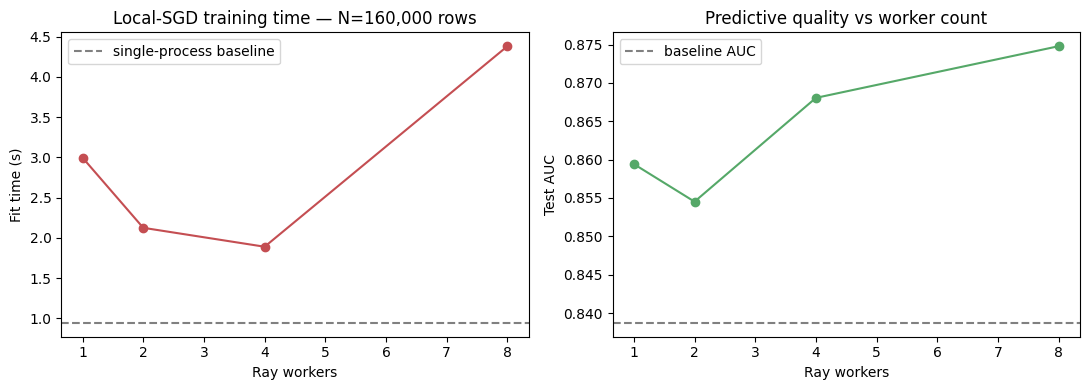

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].axhline(baseline_time, color="gray", linestyle="--", label="single-process baseline")
axes[0].plot(ray_results_df.index, ray_results_df["fit_time_s"], marker="o", color="#C44E52")
axes[0].set_xlabel("Ray workers")
axes[0].set_ylabel("Fit time (s)")
axes[0].set_title(f"Local-SGD training time — N={X_train.shape[0]:,} rows")
axes[0].legend()

axes[1].axhline(roc_auc_score(y_test, baseline_proba), color="gray", linestyle="--", label="baseline AUC")
axes[1].plot(ray_results_df.index, ray_results_df["auc"], marker="o", color="#55A868")
axes[1].set_xlabel("Ray workers")
axes[1].set_ylabel("Test AUC")
axes[1].set_title("Predictive quality vs worker count")
axes[1].legend()

fig.tight_layout()
plt.show()

In [6]:
ray.shutdown()

## Takeaways

- Ray's per-task overhead (serialization, scheduling, object store round trips) is roughly fixed
  per communication round, regardless of how small the model is. That overhead only pays for
  itself once each worker's **local** compute (`local_epochs` passes over its shard) is large
  enough to amortize it — which is exactly the 10-20M row regime this experiment targets, not
  the small smoke-test size this notebook defaults to.
- More `rounds` (more frequent averaging) costs more wall time but keeps the sharded training
  closer to what a single unsharded SGD run would produce; `rounds=1` (pure one-shot averaging)
  is the fastest option and is a reasonable approximation for a convex problem like logistic
  regression.
- Re-run this notebook with `N_ROWS` set to 10,000,000 / 20,000,000 (after regenerating data in
  `00_...`) to see whether Ray's overhead actually pays off at the scale you asked about — at
  the smoke-test size here, the single-process baseline may well win.